# Tutorial: IEA-22 windIO blade -> OpenSG (worked example)

This notebook takes the **IEA-22-280-RWT** blade — the windIO v2 file that ships with the `windIO` package — feeds it through **OpenSG_io**, then homogenizes both the **1D-shell (RM)** and the **2D-solid** with [OpenSG-TW](https://github.com/bagla0/OpenSG-TW) and compares them.

In [1]:
import os, sys, tempfile
sys.path.insert(0, os.path.abspath(os.path.join('..', '..')))   # OpenSG_io repo root
import numpy as np, yaml, windIO
from opensg_io import load_blade, build_cross_section, emit_opensg_yaml, emit_prevabs

iea22 = os.path.join(os.path.dirname(windIO.__file__), 'examples', 'turbine', 'IEA-22-280-RWT.yaml')
OUT = tempfile.mkdtemp()
print('INPUT  windIO file :', os.path.basename(iea22))
print('OUTPUT directory   :', OUT)

INPUT  windIO file : IEA-22-280-RWT.yaml
OUTPUT directory   : C:\Users\bagla0\AppData\Local\Temp\tmpog396ueu


## 1. Load the blade

`load_blade()` auto-detects the windIO version (v2 here -> `WindIOBlade`).

In [2]:
blade = load_blade(iea22)
print('reader            :', type(blade).__name__)
print('chord  @ r=0.5    : %.3f m' % blade.scalar('chord', 0.5))
print('twist  @ r=0.5    : %.3f deg' % blade.scalar('twist', 0.5))

reader            : WindIOBlade
chord  @ r=0.5    : 4.861 m
twist  @ r=0.5    : 1.159 deg


## 2. Resolve the cross-section at a station

`build_cross_section(blade, r)` resolves the airfoil, the layup stack on each arc segment, and the shear webs at non-dimensional span `r`.

In [3]:
cs = build_cross_section(blade, r=0.5, mesh_size=0.01)
print('station r=0.5  chord=%.3f m  laminates=%d  webs=%d'
      % (cs['chord'], len(cs['laminates']), len(cs['webs'])))
inv = {v: k for k, v in cs['laminates'].items()}
for k in range(len(inv)):
    plies = ' + '.join('%s@%g(%.4f)' % (m, a, t) for (m, t, a) in inv[k])
    print('  layup_%d: %s' % (k, plies[:84]))

station r=0.5  chord=4.861 m  laminates=6  webs=3
  layup_0: gelcoat@0(0.0005) + glass_triax@0(0.0030) + glass_uniax@0(0.0140) + glass_triax@0(0.
  layup_1: gelcoat@0(0.0005) + glass_triax@0(0.0030) + medium_density_foam@0(0.0425) + glass_tr
  layup_2: gelcoat@0(0.0005) + glass_triax@0(0.0030) + carbon_uniax@0(0.0670) + glass_triax@0(0
  layup_3: gelcoat@0(0.0005) + glass_triax@0(0.0030) + glass_uniax@0(0.0110) + glass_triax@0(0.
  layup_4: gelcoat@0(0.0005) + glass_triax@0(0.0030) + carbon_uniax@0(0.0660) + glass_triax@0(0
  layup_5: glass_biax@0(0.0020) + medium_density_foam@0(0.0300) + glass_biax@0(0.0020)


## 3. Visualise it

Each skin element is coloured by its laminate; the shear webs are drawn in black.

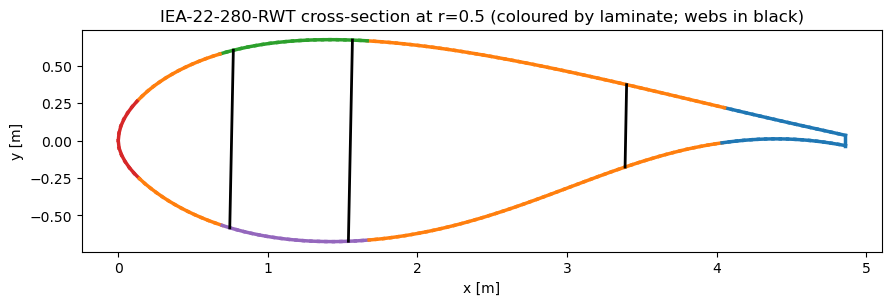

In [4]:
import matplotlib.pyplot as plt
nodes = np.asarray(cs['nodes'])
fig, ax = plt.subplots(figsize=(10, 3))
cmap = plt.get_cmap('tab10')
for (n1, n2), lam in zip(cs['elems'], cs['elem_lam']):
    p1, p2 = nodes[n1], nodes[n2]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=cmap(lam % 10), lw=2.5)
for w in cs['webs']:
    pa, pb = nodes[w['a']], nodes[w['b']]
    ax.plot([pa[0], pb[0]], [pa[1], pb[1]], 'k-', lw=2)
ax.set_aspect('equal'); ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
ax.set_title('IEA-22-280-RWT cross-section at r=0.5 (coloured by laminate; webs in black)')
plt.tight_layout(); plt.show()

## 4. Output 1 -- the 1D-shell SG YAML

`emit_opensg_yaml(cs, path)` writes the OpenSG 1D-shell SG: nodes, line elements, element sets (= laminates), sections (ply layups), materials, and per-element `e1/e2/e3` orientations.

In [5]:
shell_path = os.path.join(OUT, 'iea22_r050_shell.yaml')
info = emit_opensg_yaml(cs, shell_path)
d = yaml.safe_load(open(shell_path))
print('1D-shell YAML:', os.path.basename(shell_path))
print('  nodes=%d  elements=%d  element-sets=%d  materials=%d'
      % (len(d['nodes']), len(d['elements']), len(d['sets']['element']), len(d['materials'])))

1D-shell YAML: iea22_r050_shell.yaml
  nodes=274  elements=277  element-sets=6  materials=6


## 5. Output 2 -- the PreVABS XML (-> 2D-solid)

`emit_prevabs(cs, dir, name)` writes the PreVABS input; running PreVABS on it gives a `.sg`, which `convert_sg_to_yaml` turns into the 2D-solid SG YAML.

In [6]:
pv = os.path.join(OUT, 'iea22_r050_prevabs')
pinfo = emit_prevabs(cs, pv, name='iea22_r050')
print('PreVABS 2D-solid inputs:', sorted(os.listdir(pv)))

PreVABS 2D-solid inputs: ['iea22_r050.dat', 'iea22_r050.xml', 'materials.xml']


## 6. Homogenize the 1D shell with OpenSG-TW (RM)

The 1D-shell YAML feeds the **OpenSG-TW** MSG shell homogenizer. `rm_timoshenko_6x6` returns the Reissner–Mindlin Timoshenko **6×6** beam stiffness `[EA, GA2, GA3, GJ, EI2, EI3]`.

> Set `OPENSG_TW` to your [OpenSG-TW](https://github.com/bagla0/OpenSG-TW) checkout.

In [7]:
OPENSG_TW = os.environ.get('OPENSG_TW', os.path.expanduser('~/OpenSG-TW'))
sys.path[:0] = [OPENSG_TW, os.path.join(OPENSG_TW, 'opensg_jax')]
import jax; jax.config.update('jax_enable_x64', True)
from strip_RM import rm_timoshenko_6x6

RM = np.asarray(rm_timoshenko_6x6(shell_path, 0.0, orient=False)); RM = 0.5 * (RM + RM.T)
lbl = ['EA', 'GA2', 'GA3', 'GJ', 'EI2', 'EI3']
print('RM (1D-shell) Timoshenko 6x6 diagonal:')
for i in range(6):
    print('  %-4s %.4e' % (lbl[i], RM[i, i]))

RM (1D-shell) Timoshenko 6x6 diagonal:
  EA   2.1847e+10
  GA2  5.3406e+08
  GA3  1.9280e+08
  GJ   7.3954e+08
  EI2  7.3547e+09
  EI3  6.2956e+10


## 7. The OpenSG 2D-solid stiffness (FEniCS reference)

The same section meshed as a 2D solid and homogenized with the FEniCS (VABS-equivalent) solver in OpenSG-TW. The solid run is heavy (it runs on a server), so here we use the precomputed 6×6.

In [8]:
solid = np.array([
    [ 2.114922e+10,  0.0,          0.0,          0.0,          1.852354e+08, -3.047980e+10],
    [ 0.0,           5.158325e+08, 5.443462e+06, -1.377301e+07, 0.0,          0.0],
    [ 0.0,           5.443462e+06, 2.040810e+08, 2.332879e+08,  0.0,          0.0],
    [ 0.0,          -1.377301e+07, 2.332879e+08, 7.351436e+08,  0.0,          0.0],
    [ 1.852354e+08,  0.0,          0.0,          0.0,          7.114575e+09, -5.181811e+08],
    [-3.047980e+10,  0.0,          0.0,          0.0,         -5.181811e+08,  6.259682e+10]])
print('2D-solid Timoshenko 6x6 diagonal:')
for i in range(6):
    print('  %-4s %.4e' % (lbl[i], solid[i, i]))

2D-solid Timoshenko 6x6 diagonal:
  EA   2.1149e+10
  GA2  5.1583e+08
  GA3  2.0408e+08
  GJ   7.3514e+08
  EI2  7.1146e+09
  EI3  6.2597e+10


## 8. Compare -- % error (RM shell vs 2D-solid)

Diagonal %-error of the RM shell relative to the solid. The shell and solid agree closely — the thin-shell model captures the airfoil section well at this station.

In [9]:
print('  term   RM            2D-solid       %err')
errs = []
for i in range(6):
    e = 100 * (RM[i, i] - solid[i, i]) / solid[i, i]
    errs.append(abs(e))
    print('  %-4s  %.4e  %.4e  %+7.2f' % (lbl[i], RM[i, i], solid[i, i], e))
print('\n  max |diagonal %% error| = %.1f %%' % max(errs))

  term   RM            2D-solid       %err
  EA    2.1847e+10  2.1149e+10    +3.30
  GA2   5.3406e+08  5.1583e+08    +3.53
  GA3   1.9280e+08  2.0408e+08    -5.53
  GJ    7.3954e+08  7.3514e+08    +0.60
  EI2   7.3547e+09  7.1146e+09    +3.37
  EI3   6.2956e+10  6.2597e+10    +0.57

  max |diagonal % error| = 5.5 %


## 9. e2/e3 orientation comparison (solid vs shell)

`plot_orient` overlays the per-element material frame — **e2** = wall tangent (blue), **e3** = OML→IML normal (green on skin, red on webs) — for the **2D-solid** and the **1D-shell**, so you can confirm the two meshes use a consistent orientation.

> Set `IEA22_SOLID_YAML` to the 2D-solid YAML from the `--solid` step.

[orient_plot] SHELL: e3 OML->IML 216/277   e1_z mean=1.000


[orient_plot] SOLID: e3 OML->IML 414/461   e1_z mean=1.000


[orient_plot] wrote C:\Users\bagla0\AppData\Local\Temp\tmpog396ueu\iea22_r050_orient.png


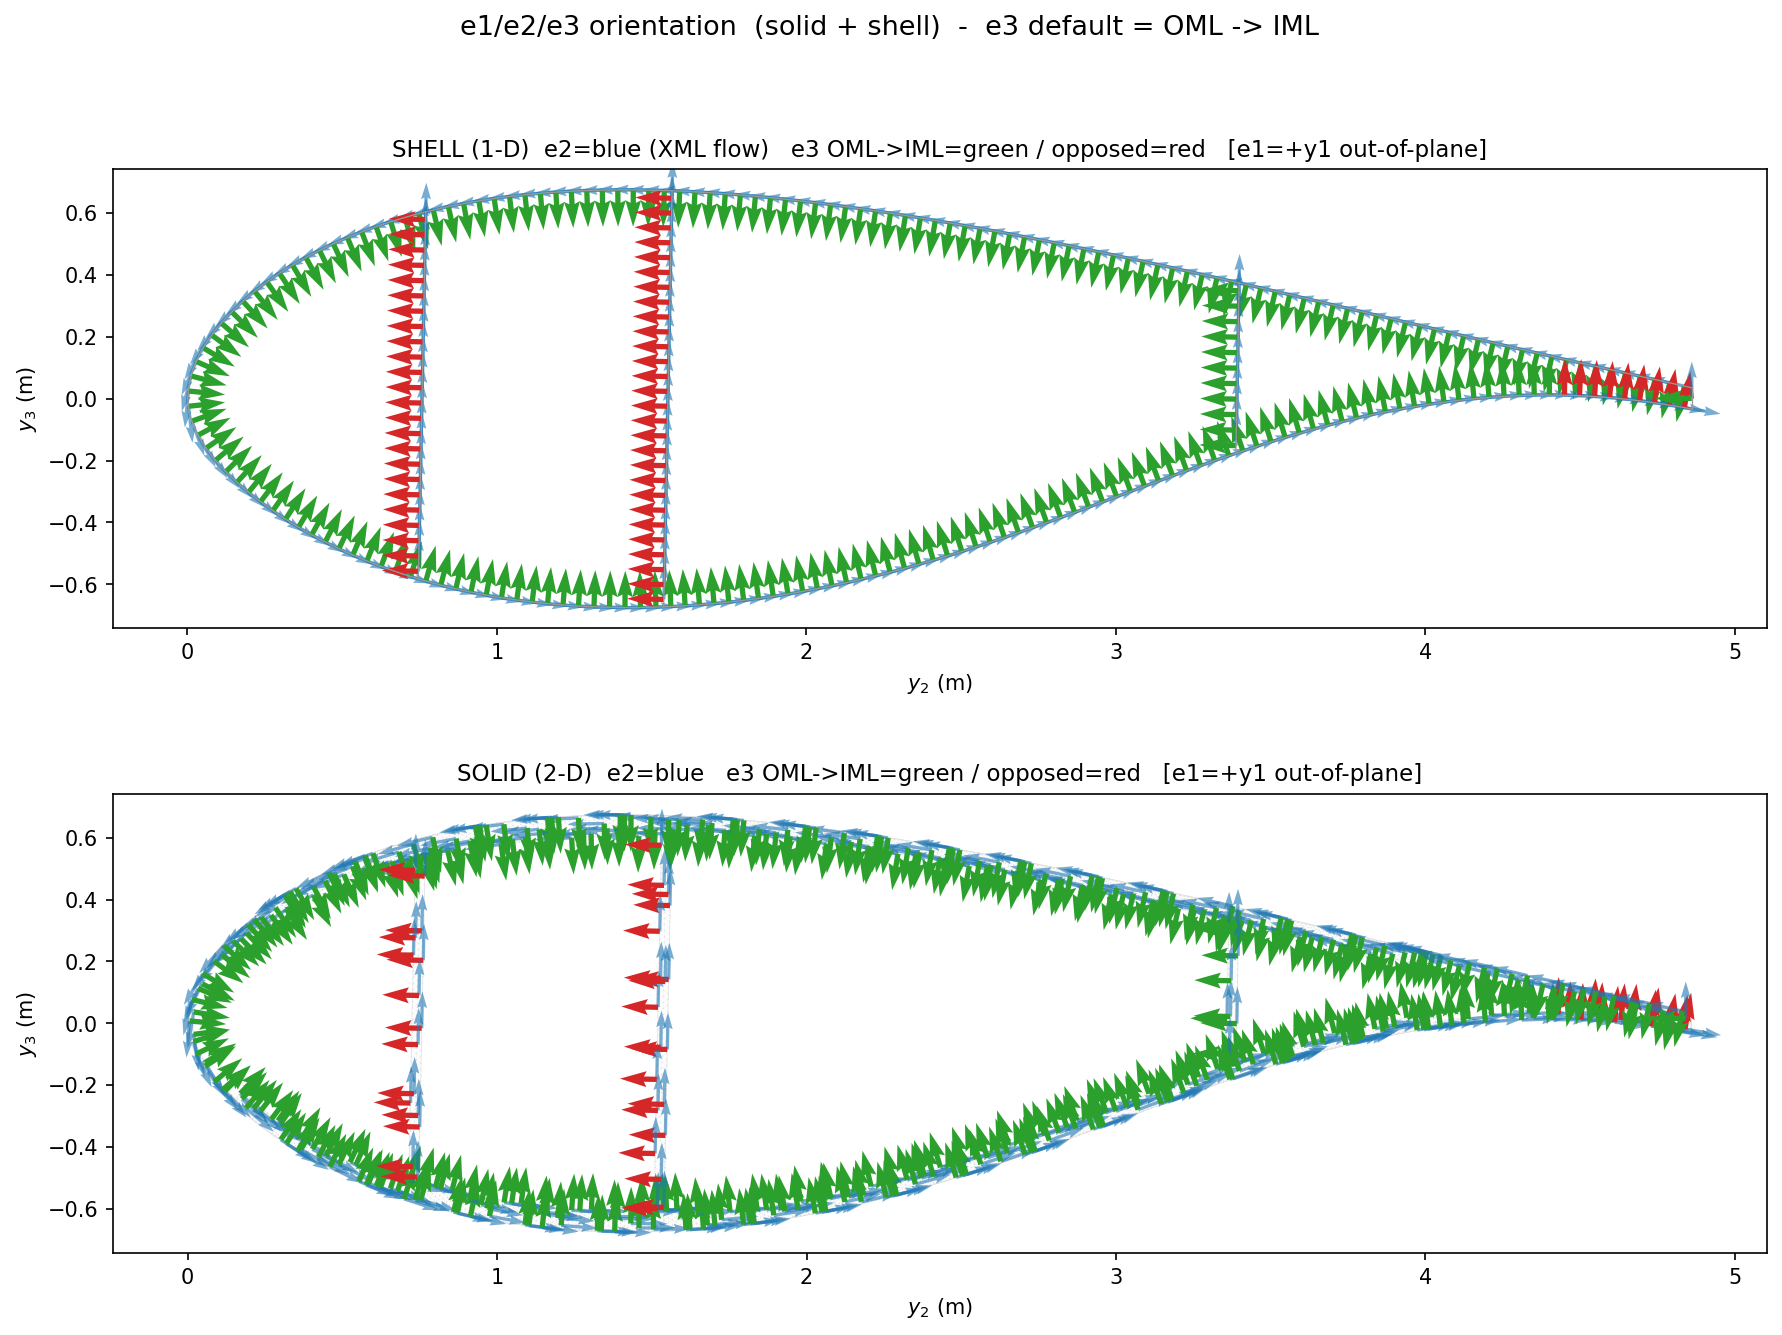

In [10]:
from fe_jax.orient_plot import plot_orient
solid_yaml = os.environ.get('IEA22_SOLID_YAML', os.path.join(OUT, 'solid_iea22_r050.yaml'))
orient_png = os.path.join(OUT, 'iea22_r050_orient.png')
plot_orient(shell_path, solid_yaml, orient_png)
from IPython.display import Image
Image(orient_png)

## Summary

From **one windIO file**, OpenSG_io produced the 1D-shell and 2D-solid SG inputs, and OpenSG-TW homogenized both:

| output | source | result |
|--------|--------|--------|
| 1D-shell SG | `emit_opensg_yaml` | RM Timoshenko 6×6 |
| 2D-solid SG | `emit_prevabs` -> PreVABS -> FEniCS | solid Timoshenko 6×6 |
| comparison | — | RM vs solid within a few % on the diagonal + matching e2/e3 orientation |

Repeat over `r = 0.1 .. 0.95` to validate the whole blade shell-vs-solid.